## ライブラリのインポート

In [70]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import japanize_matplotlib
import matplotlib.dates as mdates
from google.cloud import bigquery
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))


## pipelineの一連で前処理を実行

In [71]:
from pipeline.etl.merge_df import load_base_data
from pipeline.features.make_lag_features import make_lag_features
from pipeline.features.make_event_flag import make_event_flag
from pipeline.features.make_station_distance_features import make_station_distance_features

df2 = load_base_data()
df2 = make_lag_features(df2)
df2 = make_event_flag('expo', '../data/raw/Osaka_Events/expo_event_time_series.csv', df2)
df2 = make_event_flag('ir', '../data/raw/Osaka_Events/ir_event_time_series.csv', df2)
df2 = make_station_distance_features(df2)

/Users/shoki_u/ml-training/objective/mlit_property_price_prediction/.venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [72]:
# df2 のシェイプを確認
print(df2.shape)
# df2 のカラムの確認
print(df2.columns.tolist())
# 此花区の行を取り出し
df2[df2['municipality'] == "此花区"].head()

(43804, 46)
['id', 'type', 'price_info_class', 'municipality_code', 'municipality', 'nearest_station', 'layout', 'structure', 'use', 'future_use', 'city_planning', 'renovation', 'transaction_notes', 'transaction_price', 'coverage_ratio', 'floor_area_ratio', 'area_sqm', 'area_no_max_limit_flag', 'building_year', 'building_before_war_flag', 'time_range_write_flag', 'time_no_max_limit_flag', 'time_to_station', 'transaction_year', 'transaction_quarter', 'actual_foreign_guests', 'foreign_male_counts', 'foreign_female_counts', 'total_counts', 'include_foreign_household_counts', 'facility_count', 'price_per_sqm', 'median_price_1year_ago', 'median_price_2year_ago', 'median_price_3year_ago', 'median_price_4year_ago', 'median_price_5year_ago', 'expo_announcement_flag', 'expo_development_start_flag', 'expo_development_completion_flag', 'expo_implementation_flag', 'ir_announcement_flag', 'ir_development_start_flag', 'ir_development_completion_flag', 'ir_implementation_flag', 'distance_to_yumeshima

,id,type,price_info_class,municipality_code,municipality,nearest_station,layout,structure,use,future_use,...,median_price_5year_ago,expo_announcement_flag,expo_development_start_flag,expo_development_completion_flag,expo_implementation_flag,ir_announcement_flag,ir_development_start_flag,ir_development_completion_flag,ir_implementation_flag,distance_to_yumeshima_km
13,8dba9cfb-d79f-431e-84a3-9af963792a4d,中古マンション等,不動産取引価格情報,27104,此花区,安治川口,３ＬＤＫ,ＲＣ,住宅,住宅,...,342857.142857,1,1,0,0,1,0,0,0,5.553492
96,0e65f001-07d5-48b8-93c6-6d88ba1130da,中古マンション等,不動産取引価格情報,27104,此花区,ユニバーサルシティ,NaN,ＲＣ,NaN,住宅,...,271794.871795,1,1,0,0,1,0,0,0,4.833863
97,bdd35f75-3850-4711-80ee-df03f2d6c1ea,中古マンション等,不動産取引価格情報,27104,此花区,ユニバーサルシティ,NaN,ＳＲＣ,NaN,NaN,...,271794.871795,1,1,0,0,1,0,0,0,4.833863
98,f932d068-3099-4429-bedc-773ef7a8280d,中古マンション等,不動産取引価格情報,27104,此花区,西九条,３ＬＤＫ,ＲＣ,住宅,住宅,...,271794.871795,1,1,0,0,1,0,0,0,7.776143
166,ab00cfbc-13f3-4656-95e1-62352867ff93,中古マンション等,不動産取引価格情報,27104,此花区,伝法,３ＬＤＫ,ＳＲＣ,住宅,住宅,...,261538.461538,1,1,0,0,1,0,0,0,7.039255


In [73]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 43804 entries, 0 to 43803
Data columns (total 46 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                43804 non-null  str    
 1   type                              43804 non-null  str    
 2   price_info_class                  43804 non-null  str    
 3   municipality_code                 43804 non-null  str    
 4   municipality                      43804 non-null  str    
 5   nearest_station                   43804 non-null  str    
 6   layout                            39418 non-null  str    
 7   structure                         43070 non-null  str    
 8   use                               35852 non-null  str    
 9   future_use                        40205 non-null  str    
 10  city_planning                     43755 non-null  str    
 11  renovation                        34309 non-null  str    
 12  transaction_not

In [74]:
df2.columns

Index(['id', 'type', 'price_info_class', 'municipality_code', 'municipality',
       'nearest_station', 'layout', 'structure', 'use', 'future_use',
       'city_planning', 'renovation', 'transaction_notes', 'transaction_price',
       'coverage_ratio', 'floor_area_ratio', 'area_sqm',
       'area_no_max_limit_flag', 'building_year', 'building_before_war_flag',
       'time_range_write_flag', 'time_no_max_limit_flag', 'time_to_station',
       'transaction_year', 'transaction_quarter', 'actual_foreign_guests',
       'foreign_male_counts', 'foreign_female_counts', 'total_counts',
       'include_foreign_household_counts', 'facility_count', 'price_per_sqm',
       'median_price_1year_ago', 'median_price_2year_ago',
       'median_price_3year_ago', 'median_price_4year_ago',
       'median_price_5year_ago', 'expo_announcement_flag',
       'expo_development_start_flag', 'expo_development_completion_flag',
       'expo_implementation_flag', 'ir_announcement_flag',
       'ir_development_sta

In [75]:
print('【間取り一覧】')
print(df2['layout'].unique())
print('----' * 10)
print('【用途一覧】')
print(df2['use'].unique())
print('----' * 10)
print('【将来の用途一覧】')
print(df2['future_use'].unique())
print('----' * 10)
print('【取引内容】')
print(df2['transaction_notes'].unique())
print('----' * 10)
print('【リノベ内容】')
print(df2['renovation'].unique())



【間取り一覧】
<ArrowStringArray>
[   '２ＬＤＫ',      '１Ｋ',       nan,     '１ＤＫ',      '１Ｒ',    '３ＬＤＫ',     '３ＤＫ',
    '１ＬＤＫ',     '２ＤＫ',    '４ＬＤＫ',  '１ＬＤＫ＋Ｓ',      '２Ｋ',  '２ＬＤＫ＋Ｓ', 'オープンフロア',
      '２Ｌ',      '３Ｋ',     '４ＤＫ',      '４Ｋ',      '５Ｋ',    '５ＬＤＫ',  '３ＬＤＫ＋Ｓ',
  '４ＬＤＫ＋Ｓ',   'メゾネット',   '１ＤＫ＋Ｓ',    '１Ｋ＋Ｓ',   '２ＤＫ＋Ｓ',   '２ＬＫ＋Ｓ',     '５ＤＫ',
    '２Ｋ＋Ｓ',   '３ＤＫ＋Ｓ',     '１ＬＫ',      '１Ｌ',  '４ＬＤＫ＋Ｋ',  '７ＬＤＫ＋Ｓ',  '３ＬＤＫ＋Ｋ',
     '２ＬＫ']
Length: 36, dtype: str
----------------------------------------
【用途一覧】
<ArrowStringArray>
[    '住宅',      nan,    'その他',    '事務所',     '店舗',    '駐車場', '事務所、店舗',
 '住宅、事務所',     '倉庫',  '住宅、店舗',  '住宅、倉庫']
Length: 11, dtype: str
----------------------------------------
【将来の用途一覧】
<ArrowStringArray>
['住宅', 'その他', '事務所', nan, '店舗']
Length: 5, dtype: str
----------------------------------------
【取引内容】
<ArrowStringArray>
[nan, '調停・競売等', '関係者間取引', '瑕疵有りの可能性', 'その他事情有り', '関係者間取引、瑕疵有りの可能性']
Length: 6, dtype: str
----------------------------------------
【リノベ内容】
<ArrowStringArra

## EDA可視化

### 時系列で可視化しやすいようにデータを加工

In [76]:
from statsmodels.tsa.seasonal import STL

In [77]:
# 区×年×四半期の組み合わせに欠けがないかの確認
df2.groupby(['municipality','transaction_year','transaction_quarter']).size()

municipality  transaction_year  transaction_quarter
中央区           2014              1                      132
                                2                       97
                                3                      103
                                4                      115
              2015              1                       86
                                                      ... 
鶴見区           2024              4                       24
              2025              1                       22
                                2                       15
                                3                       15
                                4                       12
Length: 1151, dtype: int64

In [78]:
# 組み合わせの計算と実データとの照らし合わせ

# 区×年×四半期のデータ数を取得する
counts = df2.groupby(['municipality', 'transaction_year', 'transaction_quarter']).size()

# 区×年×四半期の全ての組み合わせを取得する
full_index = pd.MultiIndex.from_product(
    [df2['municipality'].unique(), df2['transaction_year'].unique(), df2['transaction_quarter'].unique()],
    names=['municipality', 'transaction_year', 'transaction_quarter']
)

# full_indexを基準にcountsのデータを整理し、データがない場合はNanを返すメソッド
counts_full = counts.reindex(full_index)
print(counts_full[counts_full.isna()])

municipality  transaction_year  transaction_quarter
生野区           2016              2                     NaN
dtype: float64


In [79]:
# 区×年×四半期の中央値パネルの作成
median = df2.groupby(['municipality','transaction_year','transaction_quarter'])['price_per_sqm'].median()

# 区×年×四半期の全ての組み合わせを取得する
full_index = pd.MultiIndex.from_product(
    [df2['municipality'].unique(), df2['transaction_year'].unique(), df2['transaction_quarter'].unique()],
    names=['municipality', 'transaction_year', 'transaction_quarter']
)

# 生野区の2016年第二四半期をNanとして持たせる
median_full = median.reindex(full_index)

# 時系列順に並び替える
median_sort = median_full.sort_index()
median_sort

# 欠損値を前後の値から補完する
median_interpolated = median_sort.groupby(level='municipality').transform(lambda x: x.interpolate())

print(median_interpolated[median_interpolated.isna()])


Series([], Name: price_per_sqm, dtype: Float64)


### 1. トレンドの可視化

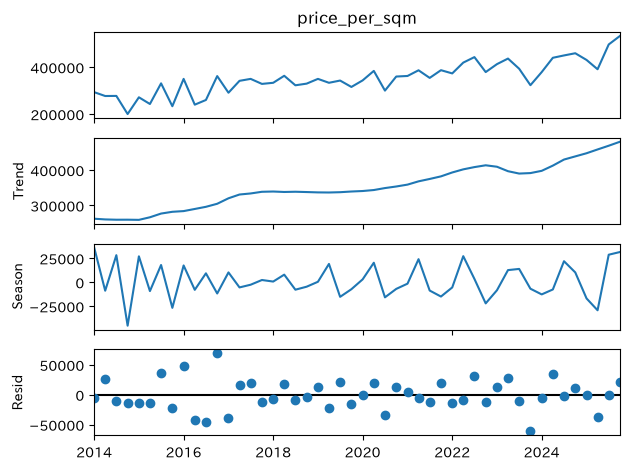

In [80]:
# 此花区だけのシリーズを取り出す
konohana_series = median_interpolated.loc['此花区']

years = konohana_series.index.get_level_values('transaction_year')
quarters = konohana_series.index.get_level_values('transaction_quarter')
period_strs = [f"{y}Q{q}" for y, q in zip(years, quarters)]

konohana_series.index = pd.PeriodIndex(period_strs, freq='Q').to_timestamp()

# STLで分解(四半期データであるため、周期は4とする)
stl = STL(konohana_series, period=4)
result_konohana = stl.fit()

# トレンド、季節性、残差をまとめてプロット
fig = result_konohana.plot()

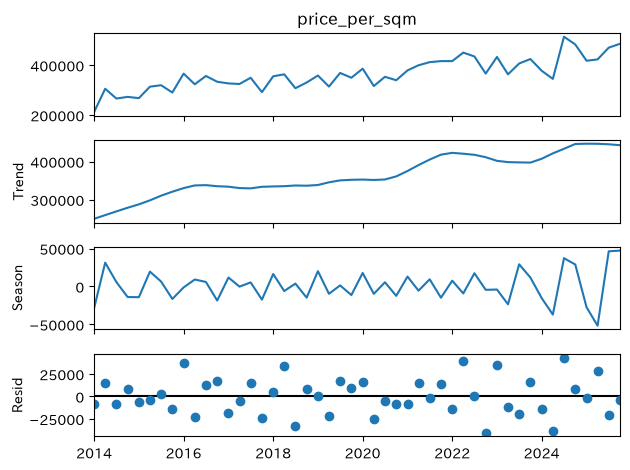

In [81]:
# 鶴見区だけのシリーズを取り出す
tsurumi_series = median_interpolated.loc['鶴見区']

years = tsurumi_series.index.get_level_values('transaction_year')
quarters = tsurumi_series.index.get_level_values('transaction_quarter')
period_strs = [f"{y}Q{q}" for y, q in zip(years, quarters)]

tsurumi_series.index = pd.PeriodIndex(period_strs, freq='Q').to_timestamp()

# STLで分解(四半期データであるため、周期は4とする)
stl = STL(tsurumi_series, period=4)
result_tsurumi = stl.fit()

# トレンド、季節性、残差をまとめてプロット
fig = result_tsurumi.plot()

In [82]:
# 年×四半期(大阪市全体)の中央値パネルの作成
median_all = df2.groupby(['transaction_year','transaction_quarter'])['price_per_sqm'].median()

# 時系列順に並び替える
median_all_sort = median_all.sort_index()

# 年と四半期の情報を取得してセットにして揃えたリストを作成
years = median_all_sort.index.get_level_values('transaction_year')
quarters = median_all_sort.index.get_level_values('transaction_quarter')
period_strs = [f"{y}Q{q}" for y, q in zip(years, quarters)]

median_all_sort.index = pd.PeriodIndex(period_strs, freq='Q').to_timestamp()

# STLで分解(四半期データであるため、周期は4とする)
stl = STL(median_all_sort, period=4)
result_all = stl.fit()


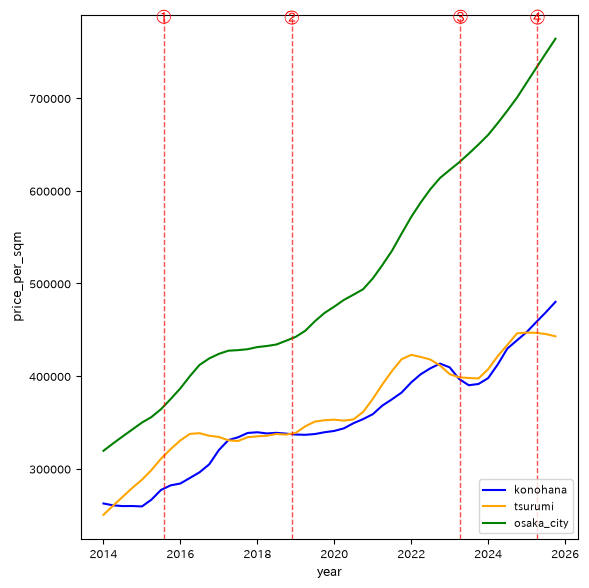

In [83]:
# 此花区と鶴見区と大阪市のトレンドを取り出す
konohana_trend = result_konohana.trend
tsurumi_trend = result_tsurumi.trend
all_trend = result_all.trend

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

ax.plot(konohana_trend.index, konohana_trend.values, color='blue', label='konohana')
ax.plot(tsurumi_trend.index, tsurumi_trend.values, color='orange', label='tsurumi')
ax.plot(all_trend.index, all_trend.values, color='green', label='osaka_city')

# イベントを番号だけで示す(説明文はスライドのテキスト側に記載する想定)
events = ['2015-07-28', '2018-11-24', '2023-04-13', '2025-04-13']
ymax = max(konohana_trend.values.max(), tsurumi_trend.values.max(), all_trend.values.max())
for i, date in enumerate(events, start=1):
    ax.axvline(x=pd.Timestamp(date), color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(pd.Timestamp(date), ymax * 1.02, f'①②③④'[i-1], color='red', fontsize=11,
            ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('year', fontsize=9)
ax.set_ylabel('price_per_sqm', fontsize=9)
ax.legend(fontsize=8, loc='lower right')
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig('trend_chart_square.png', dpi=200, bbox_inches='tight')
plt.show()

In [84]:
# 上昇率の算出
# 起工式時点(23年第二四半期)から2025年第2~4四半期までのタイムスタンプを取得
t_start = pd.Timestamp('2023-04-01')
t_end_q2 = pd.Timestamp('2025-04-01')
t_end_q3 = pd.Timestamp('2025-07-01')
t_end_q4 = pd.Timestamp('2025-10-01')

# 各カラムに扱うリストを作成
time_list = ["2025/Q2時点", "2025/Q3時点", "2025/Q4時点"]

konohana_per = [
    (konohana_trend.loc[t_end_q2] - konohana_trend.loc[t_start]) / konohana_trend.loc[t_start] * 100,
    (konohana_trend.loc[t_end_q3] - konohana_trend.loc[t_start]) / konohana_trend.loc[t_start] * 100,
    (konohana_trend.loc[t_end_q4] - konohana_trend.loc[t_start]) / konohana_trend.loc[t_start] * 100
    ]

tsurumi_per = [
    (tsurumi_trend.loc[t_end_q2] - tsurumi_trend.loc[t_start]) / tsurumi_trend.loc[t_start] * 100,
    (tsurumi_trend.loc[t_end_q3] - tsurumi_trend.loc[t_start]) / tsurumi_trend.loc[t_start] * 100,
    (tsurumi_trend.loc[t_end_q4] - tsurumi_trend.loc[t_start]) / tsurumi_trend.loc[t_start] * 100
    ]

all_per = [
    (all_trend.loc[t_end_q2] - all_trend.loc[t_start]) / all_trend.loc[t_start] * 100,
    (all_trend.loc[t_end_q3] - all_trend.loc[t_start]) / all_trend.loc[t_start] * 100,
    (all_trend.loc[t_end_q4] - all_trend.loc[t_start]) / all_trend.loc[t_start] * 100
    ]

# DF化して転置
df_per = pd.DataFrame([time_list, konohana_per, tsurumi_per, all_per]).T

# カラム名の変更
df_per.columns=["タイミング" ,"此花区(%)", "鶴見区(%)", "大阪市(%)"]

df_per

,タイミング,此花区(%),鶴見区(%),大阪市(%)
0,2025/Q2時点,15.486929,12.030037,16.142877
1,2025/Q3時点,18.15161,11.720899,18.642897
2,2025/Q4時点,21.002142,11.100069,21.146477


### 2. 残差分析

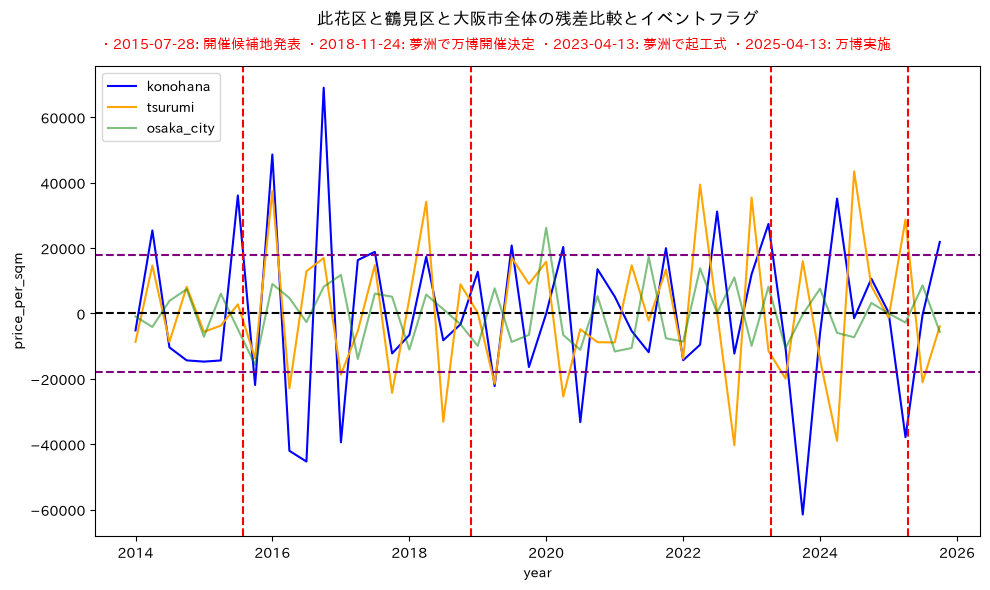

In [85]:
# 各STLオブジェクトから残差（resid）を取り出す
konohana_resid = result_konohana.resid
tsurumi_resid = result_tsurumi.resid
all_resid = result_all.resid

# しきい値（1.96σ）を計算する（ここでは大阪市全体（all_resid）を基準に計算するのが綺麗です）
sigma = all_resid.std()
upper_limit = 1.96 * sigma
lower_limit = -1.96 * sigma

# グラフの箱（fig, ax）を作る
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# 此花区と鶴見区と大阪市の残差を色分けして重ねて描画
ax.plot(konohana_resid.index, konohana_resid.values, color='blue', label='konohana')
ax.plot(tsurumi_resid.index, tsurumi_resid.values, color='orange', label='tsurumi')
ax.plot(all_resid.index, all_resid.values, color='green', label='osaka_city', alpha=0.5)
ax.set_title("此花区と鶴見区と大阪市全体の残差比較とイベントフラグ", pad=30)

# y=0の基準線と閾値の線を引く
ax.axhline(y=0, color='black', linestyle='--')
ax.axhline(y=upper_limit, color='purple', linestyle='--')
ax.axhline(y=lower_limit, color='purple', linestyle='--')

# イベントが起こったタイミングに赤線を引く
y_list = ['2015-07-28', '2018-11-24', '2023-04-13', '2025-04-13']
for y in y_list:
    ax.axvline(x=pd.Timestamp(ts_input=y), color='red', linestyle='--')

# 赤線の中身の説明を追加
event_text = "・2015-07-28: 開催候補地発表 ・2018-11-24: 夢洲で万博開催決定 ・2023-04-13: 夢洲で起工式 ・2025-04-13: 万博実施"
fig.text(x=0.5, y=0.91, s=event_text, ha='center', color='red')

ax.set_xlabel('year')
ax.set_ylabel('price_per_sqm')
plt.tight_layout()
ax.legend()
plt.show()

In [86]:
# 残差の大きいものと小さいものを取り出す
print("【過熱スパイクのデータ】")
print(konohana_resid.sort_values(ascending=False).head(3))

print("【急冷スパイクのデータ】")
print(konohana_resid.sort_values(ascending=True).head(3))

# 2015年7月28日に、万博開催の候補地を発表している
# 2016年1月14日に、大阪市が安倍政権に対して万博誘致の協力要請
# 2016年11月9日に、「22025日本万国博覧会誘致委員会準備会」を発足し、構想案を政府に提出
# 2023年7月1日に、海外パビリオン建設申請0
# 2023年10月16日に、大阪万博の建設費増加の可能性を示唆
# 2023年11月2日に、万博の建設費1.9倍を受け入れ

【過熱スパイクのデータ】
2016-10-01    69032.507055
2016-01-01    48616.005977
2015-07-01    36080.667427
Name: resid, dtype: float64
【急冷スパイクのデータ】
2023-10-01   -61480.248896
2016-07-01   -45282.514593
2016-04-01   -41987.977916
Name: resid, dtype: float64


<Axes: >

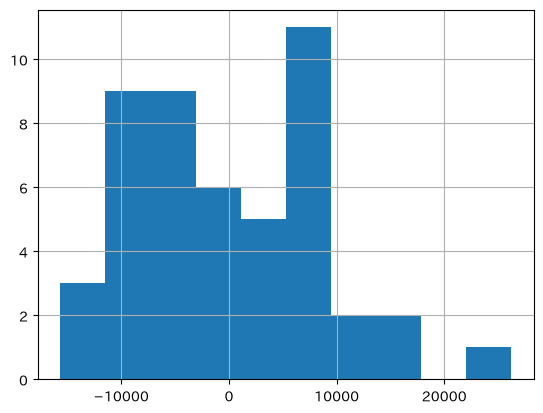

In [87]:
# ヒストグラムの可視化
all_resid.hist(bins=10)

# 二峰性らしきものは見れたが、48データと少ないため、統計的に判断するのは難しい
# ただ、「いいニュースの時はプラスに触れて、悪いニュースの時はマイナスに触れる」という解釈との整合性はとれる結果となった

### 3. 夢洲からの距離 × 取引価格の相関の推移

/var/folders/gp/vr2gz4c54kd1jns8jxndblgc0000gn/T/ipykernel_3122/1873139233.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


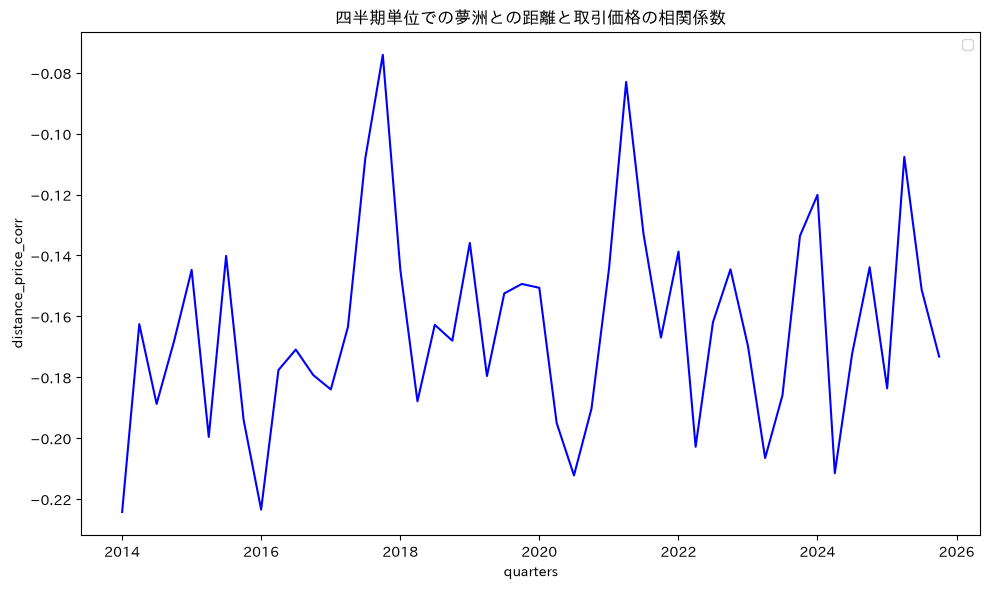

In [88]:
# 夢洲からの距離と平米数単位取引価格の計算
corr_by_quarter = df2.groupby(['transaction_year', 'transaction_quarter']).apply(lambda g: g['distance_to_yumeshima_km'].corr(g['price_per_sqm']))

# seriesを時系列順に並び替え
corr_by_quarter = corr_by_quarter.sort_index()

# 年と四半期の情報を取得してセットにして揃えたリストを作成し、PeriodIndexに変換
years = corr_by_quarter.index.get_level_values('transaction_year')
quarters = corr_by_quarter.index.get_level_values('transaction_quarter')
period_strs = [f"{y}Q{q}" for y, q in zip(years, quarters)]

corr_by_quarter.index = pd.PeriodIndex(period_strs, freq='Q').to_timestamp()

# 描画
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(corr_by_quarter.index, corr_by_quarter.values, color='blue')
ax.set_title("四半期単位での夢洲との距離と取引価格の相関係数")

ax.set_xlabel('quarters')
ax.set_ylabel('distance_price_corr')
plt.tight_layout()
ax.legend()
plt.show()

### 此花区内で物件タイプごとの可視化

In [89]:
df2['building_year'].head(10)

0    2007
1    1994
2    2017
3    1978
4    1987
5    2018
6    1983
7    1985
8    2023
9    2009
Name: building_year, dtype: Int64

In [90]:
# 此花区だけのdfを作成
df_konohana = df2[df2['municipality'] == '此花区'].copy()

# フラグの作成
df_konohana['near_station_flag'] = df_konohana['time_to_station'] <= 10
df_konohana['station_group'] = df_konohana['near_station_flag'].map({
    True: '駅徒歩10分以内（駅チカ）',
    False: '駅徒歩11分以上（駅トオ）'
})

df_konohana['build_year_flag'] = df_konohana['building_year'] >= 2000
df_konohana['build_year_group'] = df_konohana['build_year_flag'].map({
    True: '築浅',
    False: '築古'
})

df_konohana['renovation_flag'] = df_konohana['renovation'] == '改装済み'
df_konohana['renovation_group'] = df_konohana['renovation_flag'].map({
    True: 'リノベ済み',
    False: '未リノベ・不明'
})


In [91]:
# layoutの要素ごとの件数
df_konohana['layout'].value_counts()

layout
３ＬＤＫ      266
２ＬＤＫ       88
４ＬＤＫ       46
１Ｋ         33
２ＤＫ        13
１ＬＤＫ        9
３ＤＫ         7
４ＤＫ         3
２ＬＤＫ＋Ｓ      2
１ＤＫ         1
２ＤＫ＋Ｓ       1
Name: count, dtype: int64

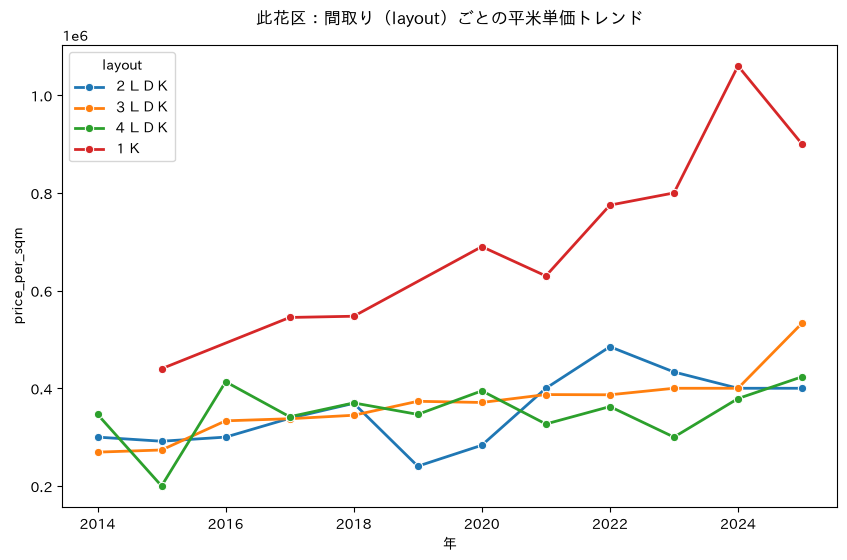

In [92]:
# layoutごとの可視化
df_layout = df_konohana.groupby(['transaction_year', 'layout'])['price_per_sqm'].median().reset_index()
target_layouts = ['３ＬＤＫ', '２ＬＤＫ', '４ＬＤＫ', '１Ｋ']

plt.figure(figsize=(10, 6))

sns.lineplot(df_layout[df_layout['layout'].isin(target_layouts)], x='transaction_year', y='price_per_sqm', hue='layout', marker='o', linewidth=2)
plt.title('此花区：間取り（layout）ごとの平米単価トレンド', pad=15)
plt.xlabel('年')
plt.ylabel('price_per_sqm')
plt.show()

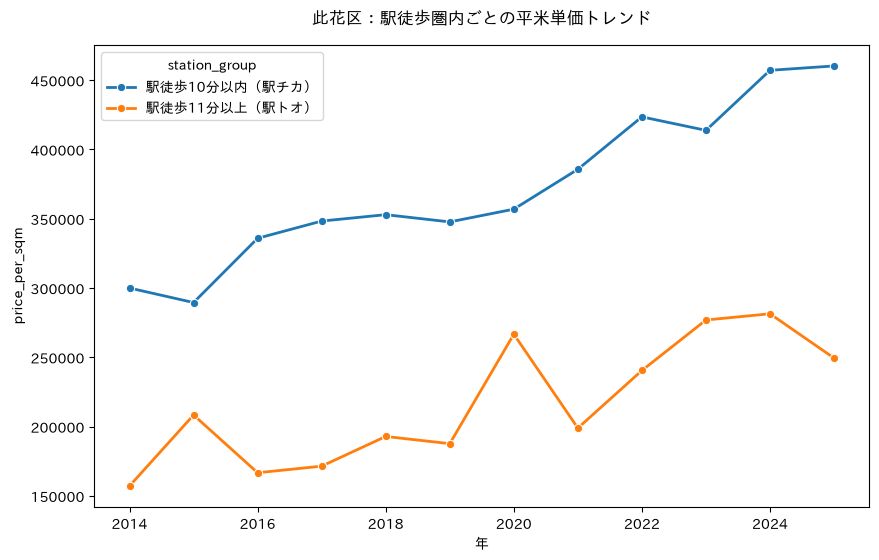

In [93]:
# 駅徒歩ごとの可視化
df_sta = df_konohana.groupby(['transaction_year', 'station_group'])['price_per_sqm'].median().reset_index()

plt.figure(figsize=(10, 6))

sns.lineplot(df_sta, x='transaction_year', y='price_per_sqm', hue='station_group', marker='o', linewidth=2)
plt.title('此花区：駅徒歩圏内ごとの平米単価トレンド', pad=15)
plt.xlabel('年')
plt.ylabel('price_per_sqm')
plt.show()


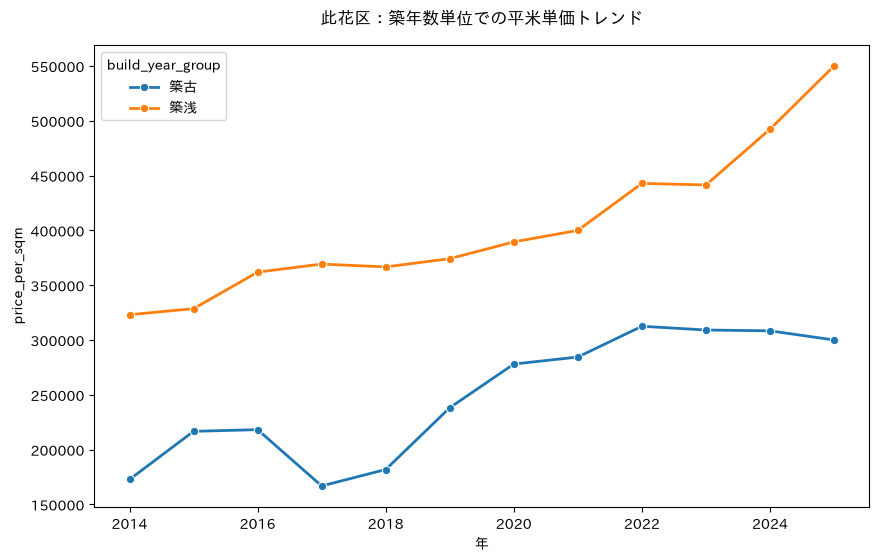

In [94]:
# 築年数ごとの可視化
df_build = df_konohana.groupby(['transaction_year', 'build_year_group'])['price_per_sqm'].median().reset_index()

plt.figure(figsize=(10, 6))

sns.lineplot(df_build, x='transaction_year', y='price_per_sqm', hue='build_year_group', marker='o', linewidth=2)
plt.title('此花区：築年数単位での平米単価トレンド', pad=15)
plt.xlabel('年')
plt.ylabel('price_per_sqm')
plt.show()

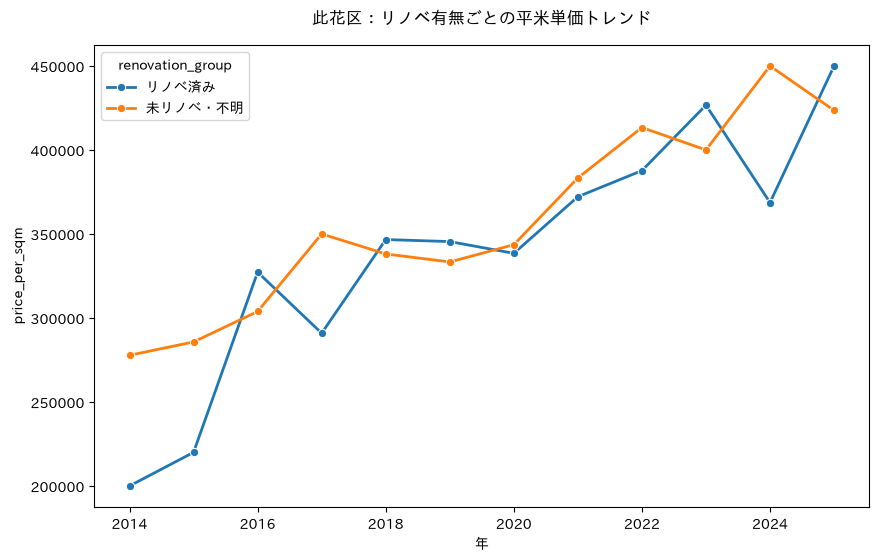

In [95]:
# リノベ有無ごとの可視化
df_renov = df_konohana.groupby(['transaction_year', 'renovation_group'])['price_per_sqm'].median().reset_index()

plt.figure(figsize=(10, 6))

sns.lineplot(df_renov, x='transaction_year', y='price_per_sqm', hue='renovation_group', marker='o', linewidth=2)
plt.title('此花区：リノベ有無ごとの平米単価トレンド', pad=15)
plt.xlabel('年')
plt.ylabel('price_per_sqm')
plt.show()

In [96]:
# structureの要素ごとの件数
df_konohana['structure'].value_counts()

structure
ＲＣ     311
ＳＲＣ    218
鉄骨造      7
Name: count, dtype: int64

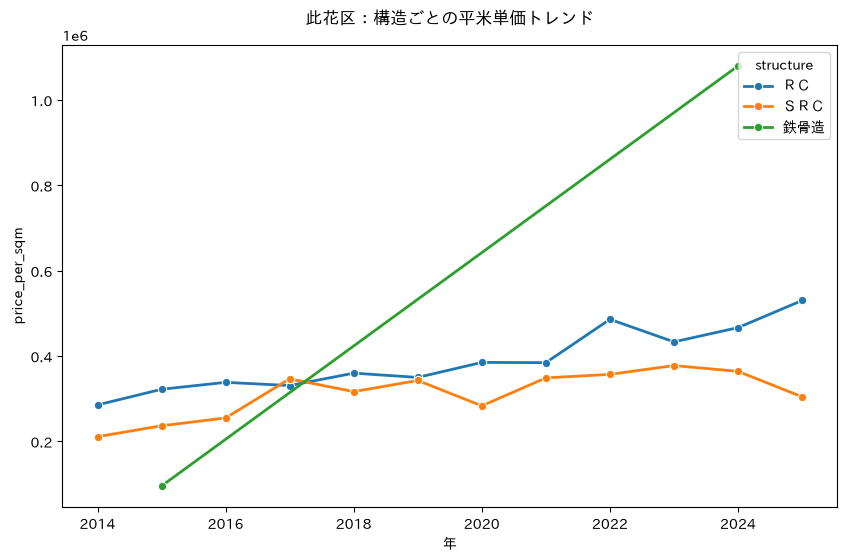

In [97]:
# 構造ごとの可視化
df_str = df_konohana.groupby(['transaction_year', 'structure'])['price_per_sqm'].median().reset_index()

plt.figure(figsize=(10, 6))

sns.lineplot(df_str, x='transaction_year', y='price_per_sqm', hue='structure', marker='o', linewidth=2)
plt.title('此花区：構造ごとの平米単価トレンド', pad=15)
plt.xlabel('年')
plt.ylabel('price_per_sqm')
plt.show()

In [102]:
def make_long_segment(df, attribute_col, attribute_name):
    tmp = df.groupby([attribute_col, 'transaction_year'])['price_per_sqm'].median().reset_index()
    tmp.columns = ['attribute_value', 'year', 'price_per_sqm']
    tmp['attribute_type'] = attribute_name
    return tmp

main_layouts = ['１Ｋ', '２ＬＤＫ', '３ＬＤＫ', '４ＬＤＫ']
df_konohana_layout = df_konohana[df_konohana['layout'].isin(main_layouts)]

segments = [
    make_long_segment(df_konohana_layout, 'layout', '間取り'),
    make_long_segment(df_konohana, 'station_group', '駅距離'),
    make_long_segment(df_konohana, 'build_year_group', '築年数'),
    make_long_segment(df_konohana, 'renovation_group', 'リノベ有無'),
]
df_segment = pd.concat(segments, axis=0)
df_segment.to_csv('../data/processed/konohana_segment_trend.csv', index=False)

In [101]:
print(df_konohana['layout'].unique())

<ArrowStringArray>
[  '３ＬＤＫ',      nan,    '２ＤＫ',   '４ＬＤＫ',   '２ＬＤＫ',    '３ＤＫ',    '４ＤＫ',
     '１Ｋ',   '１ＬＤＫ',    '１ＤＫ',  '２ＤＫ＋Ｓ', '２ＬＤＫ＋Ｓ']
Length: 12, dtype: str


In [99]:
# トレンドデータのcsv出力
tsurumi = tsurumi_trend.reset_index()
konohana = konohana_trend.reset_index()
all = all_trend.reset_index()

tsurumi.columns = ['date', 'price_per_sqm']
konohana.columns = ['date', 'price_per_sqm']
all.columns = ['date', 'price_per_sqm']

tsurumi['group'] = '鶴見区'
konohana['group'] = '此花区'
all['group'] = '大阪市'

df_trend = pd.concat([tsurumi, konohana, all], axis=0)

df_trend.to_csv('../data/processed/trend_compare_konohana_tsurumi_osakacity.csv', index=False)


In [100]:
# イベントデータ用のcsv出力
df_events = pd.DataFrame({
    'date': ['2015-07-28', '2018-11-24', '2023-04-13', '2025-04-13'],
    'label': ['候補地発表', '開催決定', '起工式', '万博開催'],
})
df_events.to_csv('../data/processed/expo_event_dates.csv', index=False)